[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/02_data_science/A4_forecasting_foundation_models.ipynb)

> 📎 **Appendix notebook — reference style.** This is one of the optional appendices (see `README.md`). Unlike the main course notebooks, appendices are written as a demo / reference: they focus on *seeing* a library at work rather than on interactive exercises. You won't find the full Solution / Debug-me / Self-assessment scaffolding here. Each appendix is built to run end-to-end *without* the optional library — it falls back to a small built-in stand-in (or skips the library-specific cells), so you can read and run it offline. Install the optional library (see the **Install** section below) to swap the stand-in for the real thing.

---
# 📓 Notebook A4 (DS) — Forecasting Foundation Models (TimesFM, Chronos, TabPFN-TS)

> **Module:** Data Science · **Type:** Appendix · **Estimated time:** 45–60 min · **Difficulty:** Intermediate

In 2024 the forecasting world had its *ChatGPT moment*: pretrained foundation models that **zero-shot a forecast** on a series they've never seen, often matching well-tuned classical models out of the box.

This notebook surveys the three you'll hear about most:

- **Google TimesFM** — decoder-only, patch-based, pretrained on ~100 B time points.
- **Amazon Chronos** — re-uses T5 by *quantising* time-series values into tokens.
- **PriorLabs TabPFN-TS** — the TabPFN idea (NB A4 in ML), specialised to forecasting.

We show the API for each, run an offline-proxy comparison, and discuss when foundation models help and when classical still wins.

---

## ✅ Prerequisites
- Notebook 11 + A1 + A2 + A3 (forecasting foundations to deep learning).
- Notebook A4 (ML) — TabPFN.

## 📦 Install (each is optional)

```bash
# Google TimesFM
pip install timesfm

# Amazon Chronos (multiple sizes — try the small one first)
pip install chronos-forecasting

# PriorLabs TabPFN-TS
pip install tabpfn-time-series
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

from sklearn.metrics import mean_absolute_error


## 1. What's a "forecasting foundation model"?

The deep-learning forecasters from A3 are trained on **your** series. A foundation model is pretrained on **billions of points across thousands of series** — finance, retail, energy, traffic, web logs — and applied **zero-shot** to your series.

The leap mirrors the language-model story: instead of "fit a model to my data," you "send your data through a model that already understands time-series structure."

| Model | Architecture | Tokenisation | Released | Hosted? |
|---|---|---|---|---|
| **TimesFM** | Decoder transformer, patches of 32 | float patches | 2024 (Google) | open-weights on HF |
| **Chronos** | T5 encoder-decoder | quantised value bins | 2024 (Amazon) | open-weights on HF |
| **Moirai** | Multi-scale masked encoder | float patches | 2024 (Salesforce) | open-weights |
| **TabPFN-TS** | Prior-fitted network | tabular features over time | 2024 (PriorLabs) | open + PriorLabs cloud |
| **Lag-Llama** | Decoder LLM | scaled lag features | 2024 | open-weights |


### 🔬 What actually happens — "no training at use time"

Section 1 said a foundation model is applied **zero-shot**. That word hides the whole punchline, so let's slow it right down. The crux is *where the "learning from your data" step goes* — and the answer is: **it doesn't happen at all when you forecast.**

**The classical recipe (A1–A3: ARIMA, Prophet, an LSTM).** Every time you get a new series, you run a *training loop* that bends the model's parameters to fit *that one series*:

```text
   your series ──► [ fit / train ]  ──► model tuned for THIS series ──► forecast
                    ▲  ^^^^^^^^^^
                    │  a loop runs HERE, every time, per series
                    └─ minutes of compute, hyper-params to tune
```

**The foundation-model recipe (TimesFM, Chronos, Moirai).** The expensive learning already happened **once**, on millions of *other* series, by the model's authors. You never run it. At use time you just *show the model your history* and read off the answer:

```text
   [ pretrained ONCE on millions of series ]   ◄── done by Google/Amazon, not you
                    │
                    ▼
   your history ──► [ condition on context ] ──► forecast      (NO fit loop!)
                    ^^^^^^^^^^^^^^^^^^^^^^^^
                    just a forward pass — milliseconds, no tuning
```

The history you pass in is called the **context** (exactly like the prompt you feed an LLM). The model has *never seen your series* and *does not change* — it reads the context and continues the pattern. That is what "in-context" and "zero-shot" mean here.

> 🧠 **One-line mental model:** *a forecasting foundation model is an LLM for time series* — pretrained broadly once, then you **condition on your history** to get a forecast. No fitting at use time; the history is the prompt.


### Train-per-series vs pretrained-then-condition — the distinction

The two recipes differ on almost every axis. This table is the one to keep:

| | **Classical (ARIMA / Prophet / LSTM)** | **Foundation model (Chronos / TimesFM)** |
|---|---|---|
| When does learning happen? | **At use time**, on *your* series | **Once, ahead of time**, on millions of *other* series |
| Per-series training loop? | **Yes** — every new series re-fits | **No** — forecasting is a forward pass |
| What you provide | the series **+** hyper-parameters to tune | just the **history (context)** |
| Time to first forecast | minutes (fit) | instant (no fit) |
| Hardware | a CPU is usually fine | bigger model → wants a GPU |
| Control / interpretability | high (you see the AR terms, the trend) | low (a black-box forward pass) |
| Domain quirks (your promo spikes) | can be modelled explicitly | only if similar patterns were in pretraining |

**A twist worth knowing: tokenisation.** Section 4 mentions Chronos *bins values into token IDs*. That's the LLM analogy taken literally: it chops the numeric range into buckets, turns each value into a bucket-ID (a "word"), and then **predicts the next token** — the very same machinery as a language model predicting the next word. TimesFM instead uses *patches* of 32 numbers as its tokens. Either way the slogan holds: **history goes in as tokens, the next tokens come out as the forecast.**

> 🎯 **Why zero-shot is attractive:** instant, no per-series tuning, one model for thousands of series. **Why it isn't a free lunch:** it's a heavyweight black box (compute), you lose the knobs and transparency of a fitted model, and it can miss domain-specific quirks it never saw in pretraining. Neither recipe wins everywhere — that's exactly why this notebook benchmarks them.


### 🧪 A tiny OFFLINE analogy — "history in, forecast out, no fitting"

The real models need GPUs and big downloads, so here is a **deliberately simplified, offline numpy analogy** that captures the *one structural idea* that makes foundation models feel different: **you call one function, hand it the history, and a forecast comes back — there is no `.fit()` step, no training loop, no parameters being tuned to your series.**

⚠️ **This is an analogy, NOT how a real foundation model computes.** A real FM is a giant pretrained transformer. Our toy below just **detects the dominant period in the history and repeats it** (a *seasonal-naive* forecaster). The point is purely the *shape of the call*: `forecast(history, horizon)` with no fitting — the same call-shape you'd use for Chronos or TimesFM.


In [ ]:
# 🧪 OFFLINE ANALOGY — numpy/stdlib only, seeded. NOT a real foundation model.
# It illustrates ONLY the call-shape: history goes IN, forecast comes OUT, no .fit().
import numpy as np

rng_demo = np.random.default_rng(7)

def zeroshot_forecast(history, horizon):
    """Forecast `horizon` steps from `history` with NO training step.

    'Pretrained knowledge' here = the single hard-coded rule
    'find the dominant period and repeat it'. A real FM replaces this
    rule with a transformer pretrained on millions of series — but the
    CALL is identical: you pass history + horizon, you get a forecast.
    """
    h = np.asarray(history, dtype=float)

    # --- "in-context" step: read structure straight from the history ---
    # Detect the dominant seasonal period via autocorrelation (no fitting!).
    scores = {}
    for p in range(2, min(len(h) // 2, 60) + 1):          # try periods 2..60
        a, b = h[:-p], h[p:]
        scores[p] = np.corrcoef(a, b)[0, 1] if len(a) > 1 else -np.inf
    best_score = max(scores.values())
    # Prefer the SMALLEST (fundamental) period that is nearly as good as the best,
    # so the cycle length 14 wins over its multiples 28, 42, ...
    best_p = min(p for p, s in scores.items() if s >= best_score - 0.02)

    # --- forecast: continue the detected season + recent level ---
    season = h[-best_p:] - h[-best_p:].mean()             # shape of one cycle
    level  = h[-best_p:].mean()                            # recent average level
    reps   = int(np.ceil(horizon / best_p))
    fc     = (np.tile(season, reps) + level)[:horizon]
    return fc, best_p

# Build a toy series WITH NO MODEL FITTING involved anywhere:
t      = np.arange(200)
hist   = 20 + 5 * np.sin(2 * np.pi * t / 14) + rng_demo.normal(0, 0.4, size=200)

# ONE call. No .fit(). History in -> forecast out.
forecast, period = zeroshot_forecast(hist, horizon=14)

print(f"history length passed in : {len(hist)}")
print(f"dominant period detected  : {period}  (true period = 14)")
print(f"forecast (14 steps) out   : {np.round(forecast[:7], 2)} ...")
print("\nNotice: we NEVER called .fit() or ran a training loop.")
print("The 'knowledge' lives in the function itself, applied zero-shot to new history.")


In [ ]:
# 🧪 OFFLINE ANALOGY — toy value-BINNING (Chronos-style tokenisation), numpy only.
# Real Chronos uses 4096 bins + a T5 transformer; we use 10 bins to SEE the idea.
import numpy as np

values = np.array([20.1, 21.4, 25.0, 24.6, 19.8, 18.2, 23.3, 26.1])

# 1) Build bin edges across the value range -> each value becomes a token ID.
n_bins = 10
edges  = np.linspace(values.min(), values.max(), n_bins + 1)
tokens = np.clip(np.digitize(values, edges) - 1, 0, n_bins - 1)   # value -> token ID

print("raw values :", values)
print("token IDs  :", tokens, "  <- the series as 'words' (one per bin)")

# 2) A foundation model would now PREDICT THE NEXT TOKEN (like next-word in an LLM),
#    then map that token back to a value (the bin centre). We just show the mapping:
centres   = (edges[:-1] + edges[1:]) / 2
back2vals = centres[tokens]
print("bin centres:", np.round(back2vals, 2), "  <- tokens decoded back to numbers")

print("\nThat round-trip (number -> token -> number) is *exactly* why Chronos can")
print("reuse a language-model architecture: forecasting becomes next-token prediction.")


### 🧠 Mental model to carry into the rest of the notebook

- **Classical (A1–A3):** *fit a model to my series* — a training loop runs every time, per series.
- **Foundation model (this notebook):** *send my series through a model that already understands time series* — pretrained once, then **conditioned on my history**, zero-shot, no fit loop.
- The history you pass in is the **context** — the time-series equivalent of an LLM **prompt**.
- Some FMs (Chronos) literally **tokenise** values into bins and **predict the next token**, reusing language-model machinery; others (TimesFM) use **patches** of numbers as tokens. Same slogan: *history-tokens in → forecast-tokens out.*
- 💡 **Trade-off, not a winner:** zero-shot buys you *instant, tuning-free, one-model-for-everything*; it costs you *compute, control, and transparency*, and it can miss quirks it never saw in pretraining. The sections below put a strong classical baseline up against this idea so you can judge for yourself.

> ⚠️ The two cells above are **simplified offline analogies** for the *call-shape and the tokenisation idea only*. The real TimesFM / Chronos / Moirai code (shown commented-out in Sections 3–5) downloads pretrained transformer weights and runs a forward pass — but you still never train them on your series.


---

### ✋ Quick exercise (~2 min) — Zero-shot call-shape

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The `zeroshot_forecast(history, horizon)` helper above takes history in and gives a forecast out — with no `.fit()`. Build a toy series whose period is **7** (not 14), call the helper for a **21-step** horizon, and check which period it detects and how long the forecast is.

```python
t = np.arange(200)
hist7 = 30 + 4 * np.sin(2 * np.pi * t / 7)
```

In [ ]:
# ✍️ Your turn 👇
t = np.arange(200)
hist7 = 30 + 4 * np.sin(2 * np.pi * t / 7)
# Call zeroshot_forecast on hist7 with horizon=21,
# then print the detected period and the length of the returned forecast.


<details>
<summary>✅ <b>Solution</b></summary>

```python
fc7, p7 = zeroshot_forecast(hist7, horizon=21)
print("detected period :", p7)        # 7
print("forecast length :", len(fc7))  # 21
```

The helper reads the dominant period straight from the context (≈7) and returns exactly `horizon=21` values — one forward-style call, no `.fit()` and no training loop.
</details>

## 2. The same demand series (so results are comparable to A1–A3)


In [2]:
rng = np.random.default_rng(0)
n = 540
dates = pd.date_range("2024-01-01", periods=n, freq="D")
trend  = 0.04 * np.arange(n)
weekly = 8 * np.sin(2 * np.pi * np.arange(n) / 7) + 4 * np.cos(2 * np.pi * np.arange(n) / 7)
yearly = 6 * np.sin(2 * np.pi * np.arange(n) / 365)
promo  = np.where((np.arange(n) > 200) & (np.arange(n) < 220), 12, 0)
noise  = rng.normal(0, 2.5, size=n)
y      = 50 + trend + weekly + yearly + promo + noise

ts = pd.Series(y, index=dates, name="searches")
train, test = ts[:-30], ts[-30:]
print(f"train {len(train)}  test {len(test)}")


train 510  test 30


## 3. Google TimesFM — patch transformer

TimesFM uses **non-overlapping patches of 32 timestamps** as tokens. A decoder-only transformer attends across patches and predicts the next patches autoregressively.

```python
# pip install timesfm
# import timesfm
#
# tfm = timesfm.TimesFm(
#     hparams=timesfm.TimesFmHparams(
#         backend="cpu",                       # or "gpu"
#         per_core_batch_size=32,
#         horizon_len=30,
#         input_patch_len=32,
#         output_patch_len=128,
#     ),
#     checkpoint=timesfm.TimesFmCheckpoint(huggingface_repo_id="google/timesfm-1.0-200m"),
# )
#
# # Each "series" is a 1-D numpy array.
# point_forecast, full_quantiles = tfm.forecast(
#     [train.values],
#     freq=[0],          # 0 = high-frequency (daily), 1 = mid (weekly), 2 = low (monthly)
# )
# print(point_forecast.shape)     # (1, 30)
```

**Strengths**
- Excellent across many domains zero-shot.
- Returns quantile forecasts out of the box (`P10..P90`).
- Single model handles many frequencies (daily, weekly, monthly).

**Limits**
- Inference cost grows with **input length** (patches grow linearly).
- No native covariate support yet.


## 4. Amazon Chronos — *quantise* the values, reuse T5

Chronos's clever move: take the value series, scale it, **bin into 4 096 token IDs**, and feed it to a T5 (encoder–decoder). The model now treats forecasting as *next-token prediction*.

```python
# pip install chronos-forecasting
# from chronos import ChronosPipeline
# import torch
#
# pipe = ChronosPipeline.from_pretrained(
#     "amazon/chronos-t5-small",            # or -base, -large, -mini, -tiny
#     device_map="cpu",
#     torch_dtype=torch.float32,
# )
# context = torch.tensor(train.values, dtype=torch.float32)
# # Sample 20 trajectories of length 30
# samples = pipe.predict(
#     context=context,
#     prediction_length=30,
#     num_samples=20,
# )
# median = np.quantile(samples.numpy(), 0.5, axis=1).squeeze()
# low, high = np.quantile(samples.numpy(), [0.1, 0.9], axis=1).squeeze()
```

**Strengths**
- Probabilistic by construction — you sample whole trajectories.
- Multiple sizes from `tiny` (8 M) to `large` (710 M) so you can pick your speed/quality trade-off.
- Hugging Face checkpoints — easy to load.

**Limits**
- Tokenisation introduces a small accuracy cost (bin width).
- Long horizons need autoregressive rollouts (slower).


## 5. PriorLabs TabPFN-TS — prior-fitted network for time series

TabPFN-TS extends the **prior-fitted network** idea (see ML notebook A4) to time series. The model has been pretrained on millions of synthetic series; you give it your series and it returns a forecast in seconds, no fitting.

```python
# pip install tabpfn-time-series
# from tabpfn_time_series import TabPFNTimeSeries
#
# model = TabPFNTimeSeries(device="cpu", n_ensemble_configurations=4)
# forecast = model.predict(
#     y=train.values,
#     horizon=30,
#     X_train=None,          # optional regressors over the train window
#     X_test=None,           # optional regressors over the forecast window
# )
# # `forecast` returns medians + quantile bands
```

PriorLabs also exposes the **same model via a hosted API** (`tabpfn-client` — same key as TabPFN cloud). Use the cloud version when:
- The series is longer than the local cap (~10 k points).
- You don't want to manage GPU dependencies.
- You're already paying for TabPFN cloud for tabular tasks.

> ⚠️ Same privacy caveat: don't ship sensitive operational data to the cloud without checking the data-handling policy.


---

### ✋ Quick exercise (~2 min) — Decode Chronos samples

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Section 4 showed that Chronos returns a `samples` array of shape `(n_series, num_samples, prediction_length)`, which you collapse with `np.quantile`. Given the toy `samples` below (1 series, 20 trajectories, 30 steps), compute the **median** forecast and a **P10–P90** band the way Section 4 does, then report the median's shape.

```python
rng_q = np.random.default_rng(1)
samples = rng_q.normal(50, 3, size=(1, 20, 30))
```

In [ ]:
# ✍️ Your turn 👇
rng_q = np.random.default_rng(1)
samples = rng_q.normal(50, 3, size=(1, 20, 30))   # (n_series, num_samples, prediction_length)
# Collapse the 20 trajectories (axis=1) into a median forecast plus a P10/P90 band,
# then print the shape of the median.


<details>
<summary>✅ <b>Solution</b></summary>

```python
median = np.quantile(samples, 0.5, axis=1).squeeze()
low, high = np.quantile(samples, [0.1, 0.9], axis=1).squeeze()
print(median.shape)   # (30,)
```

The sampling axis is `axis=1` (the 20 trajectories); collapsing it leaves one value per forecast step, so the median has shape `(30,)` — exactly one number per horizon step. The `low`/`high` arrays give the P10–P90 band.
</details>

## 6. Offline proxy — strong classical baseline vs an "ensemble of priors"

So this notebook produces a comparable plot without any of the foundation-model weights. We approximate a foundation model with an **ensemble of strong classical/simple models** — that's *roughly* what TimesFM/Chronos learn to combine internally.


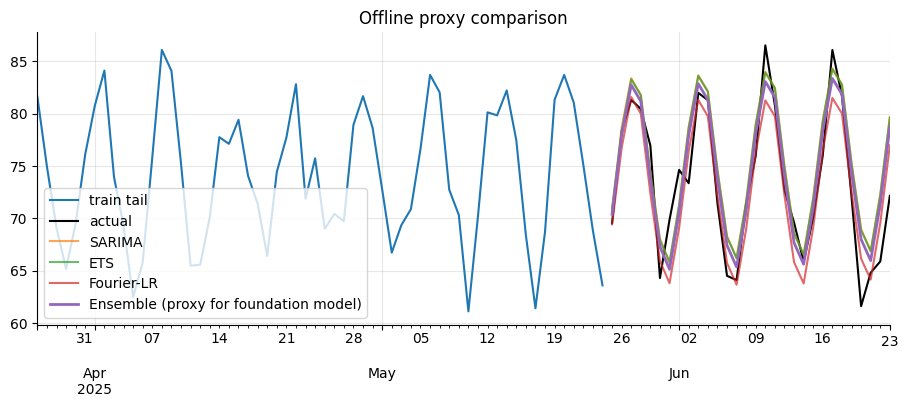

SARIMA                   MAE = 2.73
ETS                      MAE = 2.69
Fourier-LR               MAE = 2.17
Ensemble (proxy)         MAE = 2.30


In [3]:
# Simple "ensemble of priors" — average the forecast of three principled models.
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression

def fit_sarima(tr, h):
    return SARIMAX(tr, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                   enforce_stationarity=False, enforce_invertibility=False
                   ).fit(disp=False).forecast(steps=h)

def fit_ets(tr, h):
    return ExponentialSmoothing(tr, trend="add", seasonal="add", seasonal_periods=7
                                ).fit(optimized=True).forecast(steps=h)

def fit_fourier(tr, h):
    t = np.arange(len(tr))
    K = 4
    cols = [t] + [f(2 * np.pi * k * t / 7) for k in range(1, K+1) for f in (np.sin, np.cos)] \
                + [f(2 * np.pi * k * t / 365) for k in range(1, K+1) for f in (np.sin, np.cos)]
    X = np.column_stack(cols)
    reg = LinearRegression().fit(X, tr.values)
    t2 = np.arange(len(tr), len(tr) + h)
    cols2 = [t2] + [f(2 * np.pi * k * t2 / 7) for k in range(1, K+1) for f in (np.sin, np.cos)] \
                  + [f(2 * np.pi * k * t2 / 365) for k in range(1, K+1) for f in (np.sin, np.cos)]
    return pd.Series(reg.predict(np.column_stack(cols2)),
                     index=pd.date_range(tr.index[-1] + pd.Timedelta(days=1), periods=h))

H = len(test)
fc_sar = fit_sarima(train, H)
fc_ets = fit_ets(train, H)
fc_fou = fit_fourier(train, H)
# Equal-weight ensemble — what foundation models effectively learn:
fc_ens = (fc_sar.values + fc_ets.values + fc_fou.values) / 3.0
fc_ens = pd.Series(fc_ens, index=test.index)

fig, ax = plt.subplots(figsize=(11, 3.8))
ts[-90:-H].plot(ax=ax, label="train tail")
test.plot(ax=ax, color="black", label="actual")
fc_sar.plot(ax=ax, label="SARIMA", alpha=0.7)
fc_ets.plot(ax=ax, label="ETS", alpha=0.7)
fc_fou.plot(ax=ax, label="Fourier-LR", alpha=0.7)
fc_ens.plot(ax=ax, label="Ensemble (proxy for foundation model)", color="C4", linewidth=2)
ax.legend(); ax.set_title("Offline proxy comparison"); plt.show()

for name, fc in [("SARIMA", fc_sar), ("ETS", fc_ets), ("Fourier-LR", fc_fou), ("Ensemble (proxy)", fc_ens)]:
    print(f"{name:24s} MAE = {mean_absolute_error(test, fc):.2f}")


---

### ✋ Quick exercise (~2 min) — Weight the ensemble

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The proxy ensemble above averaged SARIMA, ETS, and Fourier-LR with equal weights. Build a **weighted** ensemble that trusts SARIMA twice as much as the other two (weights 2, 1, 1) and compute its test MAE. Does it beat the equal-weight ensemble?

In [ ]:
# ✍️ Your turn 👇
# Reuse fc_sar, fc_ets, fc_fou (already computed above) and mean_absolute_error.
w_sar, w_ets, w_fou = 2, 1, 1
# Build the weighted-average forecast, wrap it in a pd.Series on test.index,
# then print its test MAE.


<details>
<summary>✅ <b>Solution</b></summary>

```python
w_sar, w_ets, w_fou = 2, 1, 1
fc_w = (w_sar * fc_sar.values + w_ets * fc_ets.values + w_fou * fc_fou.values) / (w_sar + w_ets + w_fou)
fc_w = pd.Series(fc_w, index=test.index)
print(f"Weighted ensemble MAE = {mean_absolute_error(test, fc_w):.2f}")
```

Up-weighting the strongest seasonal model (SARIMA) tilts the blend toward it. Compare the printed MAE with the equal-weight ensemble above to judge whether the extra trust actually helped on this series.
</details>

## 7. When foundation models actually beat classical

Recent benchmarks (Monash Time Series Archive 2024, Salesforce TS-Bench) show:

- Foundation models **beat classical** on:
  - Many heterogeneous series at once (the model amortises its prior).
  - Short series (< 1 year) where SARIMA struggles to estimate seasonality.
  - Cold-start: a brand-new SKU with only a few weeks of history.
- Foundation models **don't (yet) consistently beat well-tuned classical** on:
  - Long, stable series with strong seasonality (SARIMA shines here).
  - Domains the prior doesn't cover well (e.g., extreme regime shifts).

**Practical workflow.** Use a foundation model as a strong zero-shot baseline. If a tuned SARIMA/ETS or a small NN beats it on rolling-origin CV, ship that. If it doesn't, you've saved yourself the tuning effort.


## 🧪 Exercises

### Exercise 1 — "Cold-start" sweep
Cut your series to the first 60, 120, 240, and 480 days. Re-run SARIMA, ETS, Fourier-LR, and the ensemble at each cut. Plot MAE vs train length. Does the gap between SARIMA and the ensemble shrink as data grows? (This mirrors the published benchmarks: foundation models lead at small N, classical catches up.)


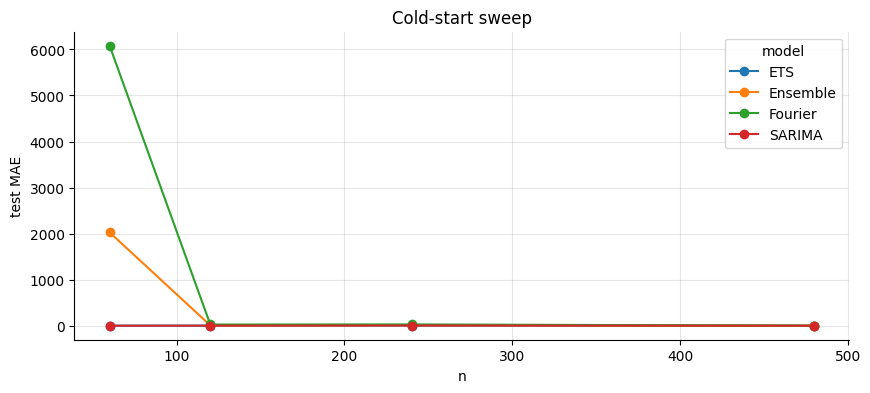

model   ETS  Ensemble  Fourier  SARIMA
n                                     
60     2.62   2027.22  6080.44    3.07
120    3.34      9.40    28.47    3.34
240    3.95     13.62    30.71    6.23
480    1.86      1.88     2.01    1.83


In [4]:
# ── Exercise 1 solution ──────────────────────────────────────────────────
H = 30
sizes = [60, 120, 240, 480]
rows = []
for s in sizes:
    sub = ts[:s + H]
    tr, te = sub[:-H], sub[-H:]
    f_s = fit_sarima(tr, H); f_e = fit_ets(tr, H); f_f = fit_fourier(tr, H)
    f_x = pd.Series((f_s.values + f_e.values + f_f.values) / 3.0, index=te.index)
    for name, fc in [("SARIMA", f_s), ("ETS", f_e), ("Fourier", f_f), ("Ensemble", f_x)]:
        rows.append((s, name, mean_absolute_error(te, fc)))
import pandas as pd
df = pd.DataFrame(rows, columns=["n", "model", "MAE"])
piv = df.pivot(index="n", columns="model", values="MAE")
piv.plot(marker="o"); plt.ylabel("test MAE"); plt.title("Cold-start sweep"); plt.show()
print(piv.round(2))


### Exercise 2 — Hybrid: foundation forecast + residual GBM
Build a hybrid: take the ensemble forecast (proxy for a foundation model) as a *baseline* on the last 60 days of train, fit a tiny GradientBoostingRegressor on the **residuals** with calendar features (`dayofweek`, `dayofyear`), then add it back. Does MAE drop? This is the canonical "foundation model + small specialist" pattern in production.


In [5]:
# ── Exercise 2 solution ──────────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingRegressor

# Build (foundation, calendar) → residual mapping on a hold-out slice of train
H = 30
backtest_n = 60
inner_tr = ts[:-(H + backtest_n)]
inner_va = ts[-(H + backtest_n):-H]
fc_inner = (fit_sarima(inner_tr, backtest_n).values
            + fit_ets(inner_tr, backtest_n).values
            + fit_fourier(inner_tr, backtest_n).values) / 3.0
res = inner_va.values - fc_inner
def calendar_feats(idx):
    return np.column_stack([idx.dayofweek.values, idx.dayofyear.values])
X_res = calendar_feats(inner_va.index)
gbm = GradientBoostingRegressor(random_state=0).fit(X_res, res)

# Apply during real test
fc_base = (fit_sarima(ts[:-H], H).values + fit_ets(ts[:-H], H).values + fit_fourier(ts[:-H], H).values) / 3.0
correction = gbm.predict(calendar_feats(test.index))
fc_hybrid = fc_base + correction

print(f"Ensemble only MAE   = {mean_absolute_error(test, fc_base):.2f}")
print(f"Ensemble + GBM MAE  = {mean_absolute_error(test, fc_hybrid):.2f}")


Ensemble only MAE   = 2.30
Ensemble + GBM MAE  = 3.13


## 🧠 Key takeaways

- **TimesFM / Chronos / TabPFN-TS / Moirai / Lag-Llama** — same idea: pretrain on enormous heterogeneous time-series corpora; zero-shot at inference time.
- They **shine on small/short/heterogeneous series**, especially cold-start.
- Well-tuned classical models still win on long, stable series with rich seasonality.
- The pragmatic production pattern is **foundation forecast + small specialist correction** (Exercise 2).
- Same privacy caveats as any cloud ML — check before sending operational data.

## 📚 References

- *TimesFM* — Google Research, ICML 2024.
- *Chronos: Learning the Language of Time Series* — Amazon Science, 2024.
- *TabPFN-TS* — PriorLabs, 2024.
- Monash Time Series Archive — https://forecastingdata.org/

## 🚀 Next step

Return to the data-science module README to see how these appendix notebooks fit the bigger learning paths, or continue to the ML appendix `A1_pytorch_foundations.ipynb` if you came from here.
